In [3]:
import numpy as np
from sklearn.datasets import load_iris, make_moons
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import export_graphviz
from graphviz import Source

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Decision Trees

Let's build one decision tree and visualize it. To understand how they make predictions.

In [4]:
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Now, using Graphviz software, we can visualize the tree's graph

In [5]:
export_graphviz(
    tree_clf,
    out_file="./pictures/iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names = iris.target_names,
    rounded=True,
    filled=True
)


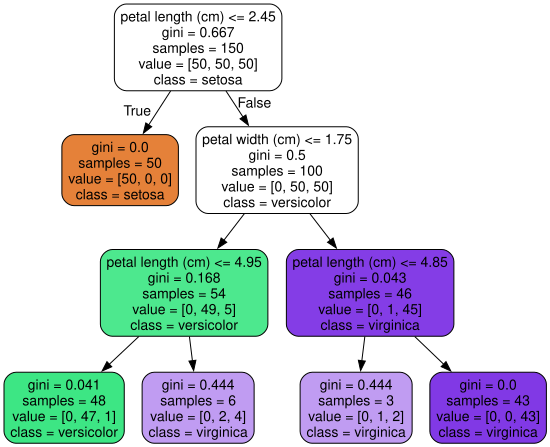

In [150]:
Source.from_file("./pictures/iris_tree.dot")

Also, we can get probabilities that the instance belong to each class

In [7]:
print(f"Predict proba{tree_clf.predict_proba([[4.3, 1.5]]).round(3)}")
print(f"Predict proba{tree_clf.predict([[4.3, 1.5]])}")

Predict proba[[0.    0.979 0.021]]
Predict proba[1]


 This probability depends on how many training instances end up in that leaf. The overwhelming number of class instances will define leaf class prediction.

# Regularization

Usually, decision trees without regularization tend to overfit the data.

SKLearn provides a couple of regularization parameters:
- `max_features` - The maximum number of features that are weighted for splitting at each node.
- `max_leaf_nodes` - The maximum number of leaves.
- `min_samples_split` - The minimum number of entries each node must have for splitting.
- `min_samples_split` - The minimum number of entries each leaf must create.
- `min_weight_fraction_leaf` - The minimum weighted fraction of the total weights. For example, if we have $100$ entries, and this parameter is set to $0.05$ _($5\%$)_, then a node is only valid if it contains $5\%$ of the total number of entries.

In [8]:
X_moons, y_moons = make_moons(n_samples=150, noise=0.2)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

X_moons_test, y_moons_test = make_moons(n_samples=100000, noise=0.2) # Random state 43 to prevent creating same moons as earlier

print(f"Unregularized tree: {tree_clf1.score(X_moons_test, y_moons_test)}")
print(f"Regularized min_samples_lear=5 tree: {tree_clf2.score(X_moons_test, y_moons_test)}")

Unregularized tree: 0.95398
Regularized min_samples_lear=5 tree: 0.88208


As we can see, regularized tree generalizes better on a test set. Let's plot decision boundaries to see how the tree overfits the data:

In [9]:
def plot_decision_tree(clf, X, y, axes = [-1, 1, -1, 1], plot_training: bool = True, configure_axes: bool = True) -> None:
    """Plots only two classes classification"""
    if configure_axes:
        axes[0], axes[1], axes[2], axes[3] = np.min(X[:, 0]) - 0.1, np.max(X[:, 0]) + 0.1, np.max(X[:, 1]) + 0.1, np.min(X[:, 1]) - 0.1

    X1s = np.linspace(axes[0], axes[1], 100)
    X2s = np.linspace(axes[2], axes[3], 100)

    x1, x2 = np.meshgrid(X1s, X2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=ListedColormap(["blue", "red"]))

    if plot_training:
        plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c="blue")
        plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c="red")

    plt.show()

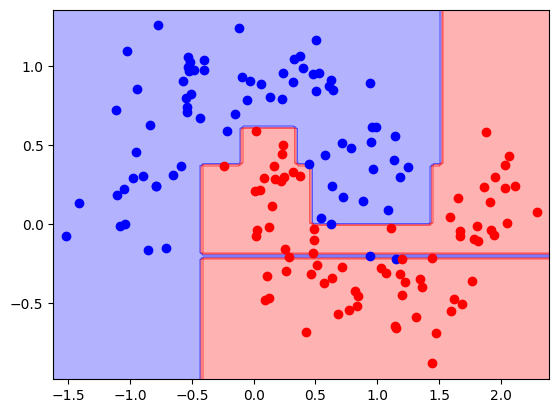

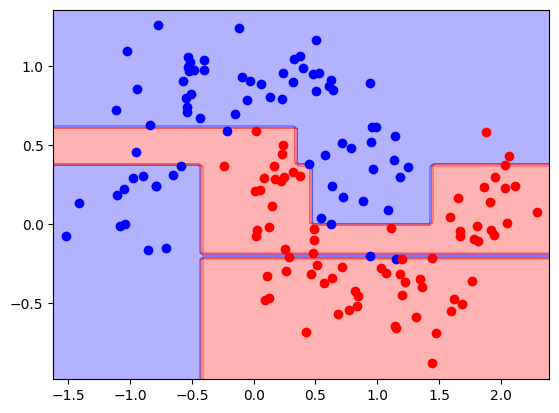

In [10]:
plot_decision_tree(tree_clf1, X_moons, y_moons, plot_training = True, configure_axes = True)
plot_decision_tree(tree_clf2, X_moons, y_moons, plot_training = True, configure_axes = True)

As we can see, tree without regularization overfitted the data.

## Regression

Decision trees can also perform regression tasks.

Let's create some quadratic dataset

In [72]:
X = np.random.rand(300, 1) - 0.5
y = X**2 + np.random.rand(300, 1) * 0.1

Now, we can train tree regressor. We won't toggle any hyperparameters, let's see how tree tends to overfit training set

In [73]:
tree_reg1 = DecisionTreeRegressor()
tree_reg1.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Function to plot training set and predictions

In [79]:
def plot_decision_tree_regression(X, y, clf, title, range_ = (-0.5, 0.5)) -> None:
    X_pred = np.linspace(range_[0], range_[1], 300).reshape(-1, 1)
    y_pred = clf.predict(X_pred)

    plt.scatter(X, y, c="blue", s=20)
    plt.plot(X_pred, y_pred, c="red",)
    plt.title(title)
    plt.grid()
    plt.show()

Plot overfitting tree

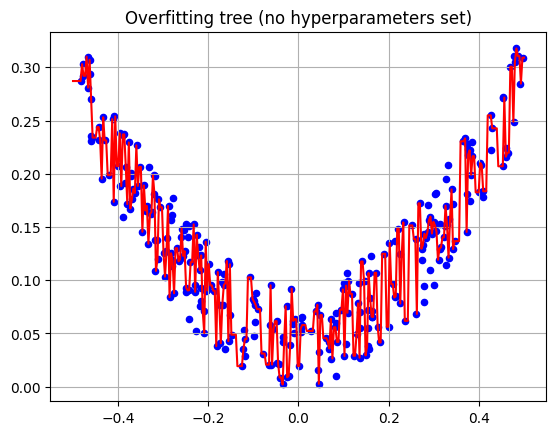

In [80]:
plot_decision_tree_regression(X, y, tree_reg1, "Overfitting tree (no hyperparameters set)",)

Plot regularized tree

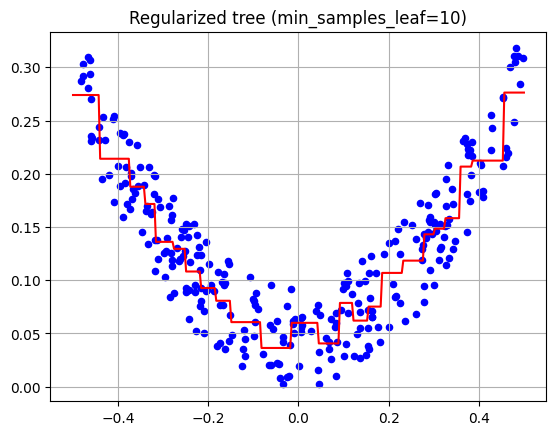

In [81]:
tree_reg2 = DecisionTreeRegressor(min_samples_leaf=10, random_state=42)
tree_reg2.fit(X, y)
plot_decision_tree_regression(X, y, tree_reg2, "Regularized tree (min_samples_leaf=10)",)

Plot tree with maximum depth set to 3

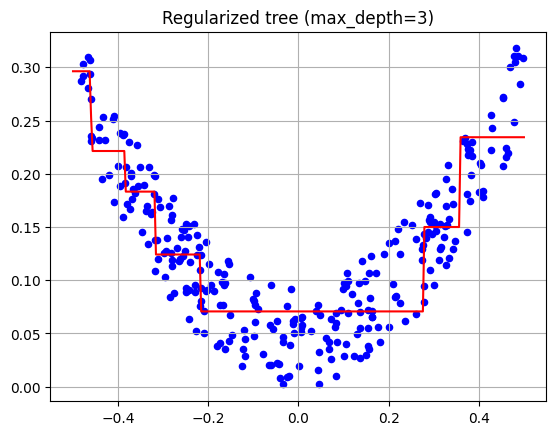

In [82]:
tree_reg_depth_3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg_depth_3.fit(X, y)
plot_decision_tree_regression(X, y, tree_reg_depth_3, "Regularized tree (max_depth=3)",)

As you can see, working with tree requires regularizing the model.

## Sensitivity to Axis Orientation

Trees are also very sensitive to the data's axis orientations. Let's create some linearly separable dataset, and rotate it by 45 degrees

In [114]:
X_1 = np.random.randint(-2, 0, (100, 1)) + np.random.rand(100, 1)
X_2 = np.random.randint(0, 2, (100, 1)) + np.random.rand(100, 1)
X = np.r_[X_1, X_2]
X = np.c_[np.random.rand(*X.shape), X]
y = np.r_[np.ones(100), np.zeros(100)]

Function to visualize decision boundaries

In [147]:
def plot_binary_classification_tree(X, y, clf, title) -> None:
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c="blue")
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c="red")

    X1, X2 = np.linspace(np.min(X[:, 0]), np.max(X[:, 0])), np.linspace(np.min(X[:, 1]), np.max(X[:, 1]))
    X1s, X2s = np.meshgrid(X1, X2)
    X_new = np.c_[X1s.ravel(), X2s.ravel()]
    grid_predictions = clf.predict(X_new).reshape(X1s.shape)
    print(grid_predictions.shape)

    plt.contour(X1s, X2s, grid_predictions, alpha=0.5)
    plt.title(title)
    plt.title(title)
    plt.show()

Training decision tree on original dataset

(50, 50)


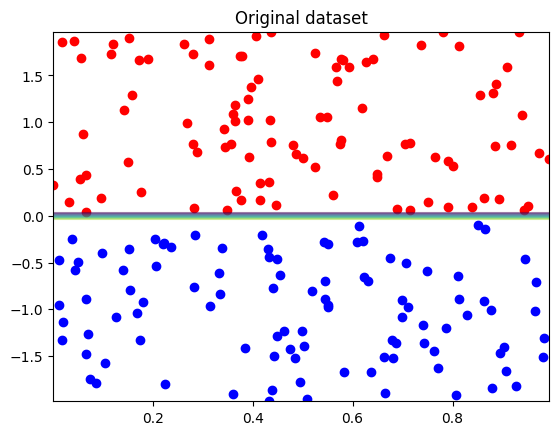

In [148]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X, y)
plot_binary_classification_tree(X, y, tree_reg, "Original dataset")

As we can see, our classifier is simple - just one decision node.

Now, let's rotate this dataset using rotation matrix.

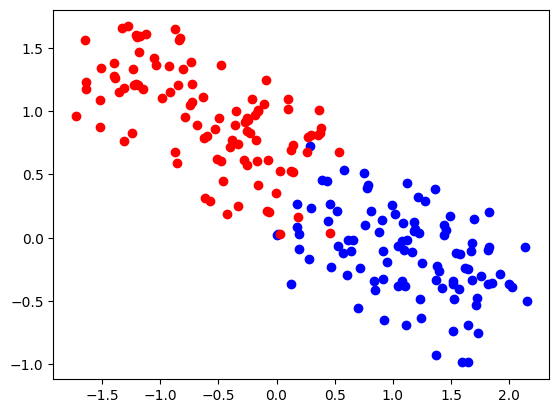

In [162]:
rotation_matrix_45 = np.array([[np.cos(45), -np.sin(45)], [np.sin(45), np.cos(45)]])

# Transposing since in programming vectors are rows.
rotated_X = rotation_matrix_45 @ X.T
rotated_X = rotated_X.T
rotated_X += np.random.randn(*rotated_X.shape) * 0.15

plt.scatter(rotated_X[:, 0][y == 1], rotated_X[:, 1][y == 1], c="blue")
plt.scatter(rotated_X[:, 0][y == 0], rotated_X[:, 1][y == 0], c="red")
plt.show()

(50, 50)


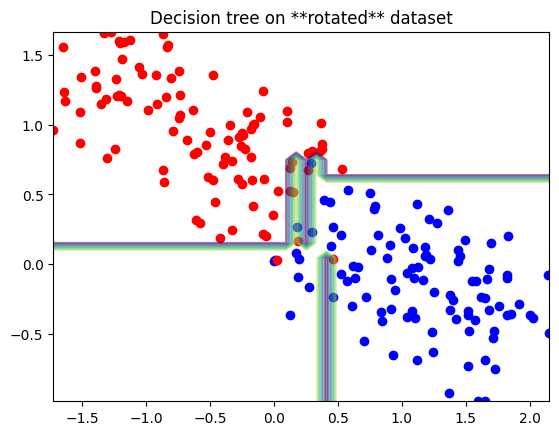

In [163]:
tree_clf = DecisionTreeClassifier()
tree_clf.fit(rotated_X, y)
plot_binary_classification_tree(rotated_X, y, tree_clf, title="Decision tree on **rotated** dataset")

As we can see - rotating leads to new decision tree. To solve this issue, you may want to use PCA, we will talk about that in future notes.